In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Data Loading
# Load the dataset

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

raw_data.shape[0]

7214

In [4]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


In [6]:
# Data Preprocessing
# Clean and prepare the dataset

df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat",
        "score_text", "sex", "priors_count",
        "days_b_screening_arrest", "decile_score",
        "is_recid", "two_year_recid",
        "c_jail_in", "c_jail_out"
    ]
].copy()

# Filters
df = df[(df["days_b_screening_arrest"] >= -30) & (df["days_b_screening_arrest"] <= 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Convert datetime
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"])
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"])

# Create factors
df["crime_factor"] = df["c_charge_degree"]

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Less than 25", "Greater than 45"]
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"]
)

df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"]
)

df["score_factor"] = np.where(df["score_text"] == "Low", 0, 1)

df.shape[0]

6172

In [7]:
# Exploratory Data Analysis (EDA)
# Examine the structure of the dataset using summary statistics and visualizations. This helps to understand the distribution of key variables such as race, gender, and risk scores.

In [8]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   object        
 2   race                     6172 non-null   object        
 3   age_cat                  6172 non-null   object        
 4   score_text               6172 non-null   object        
 5   sex                      6172 non-null   object        
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   int64         
 10  two_year_recid           6172 non-null   int64         
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

In [9]:
# Summary of age categories
print("── Age Category ──")
print(df["age_cat"].value_counts())

── Age Category ──
age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64


In [10]:
# Summary of race
print("\n── Race ──")
print(df["race"].value_counts())


── Race ──
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [11]:
# Percentage breakdown
n = len(df)
print(f"\nBlack defendants:          {df['race'].value_counts()['African-American'] / n * 100:.2f}%")
print(f"White defendants:          {df['race'].value_counts()['Caucasian'] / n * 100:.2f}%")
print(f"Hispanic defendants:       {df['race'].value_counts()['Hispanic'] / n * 100:.2f}%")
print(f"Asian defendants:          {df['race'].value_counts()['Asian'] / n * 100:.2f}%")
print(f"Native American defendants:{df['race'].value_counts()['Native American'] / n * 100:.2f}%")



Black defendants:          51.44%
White defendants:          34.07%
Hispanic defendants:       8.25%
Asian defendants:          0.50%
Native American defendants:0.18%


In [12]:
# Summary of score_text
print("\n── Score Text ──")
print(df["score_text"].value_counts())


── Score Text ──
score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [13]:
# Summary of sex
print("\n── Sex ──")
print(df["sex"].value_counts())
print(f"\nMen:   {df['sex'].value_counts()['Male'] / n * 100:.2f}%")
print(f"Women: {df['sex'].value_counts()['Female'] / n * 100:.2f}%")


── Sex ──
sex
Male      4997
Female    1175
Name: count, dtype: int64

Men:   80.96%
Women: 19.04%


In [14]:
# Two-year recidivism count
print("\n── Two-Year Recidivism ──")
print(f"Recidivated: {df['two_year_recid'].sum()} ({df['two_year_recid'].sum() / n * 100:.2f}%)")


── Two-Year Recidivism ──
Recidivated: 2809 (45.51%)


In [15]:
df["race_factor"].value_counts()
df["gender_factor"].value_counts()
df["score_factor"].value_counts()

,count
score_factor,
0,3421
1,2751


In [16]:
# Sex x Race Crosstab
print("\n── Sex x Race Crosstab ──")
print(pd.crosstab(df["sex"], df["race"]))


── Sex x Race Crosstab ──
race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [17]:
# Correlation
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
corr = df["length_of_stay"].corr(df["decile_score"])
print(f"\nCorrelation between length of stay and decile score: {corr:.4f}")


Correlation between length of stay and decile score: 0.2075


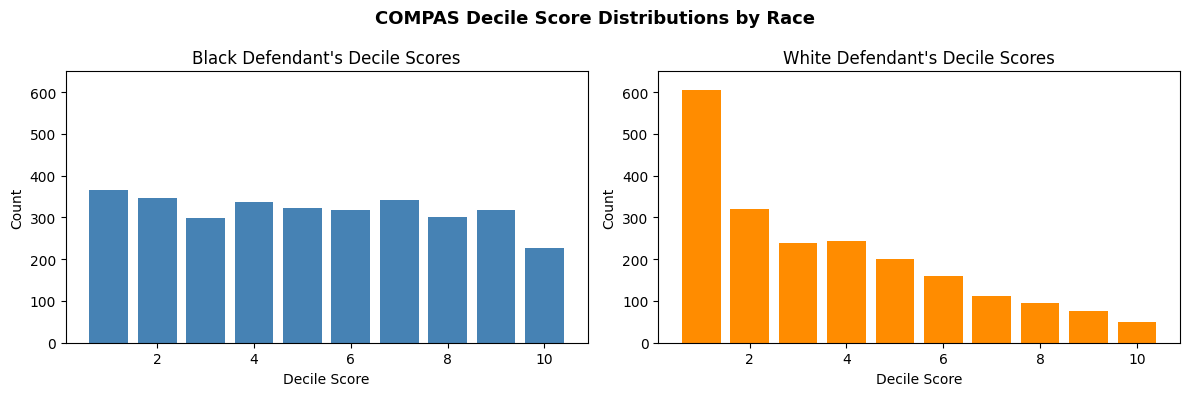

In [18]:
# Decile Score Bar Charts (Black vs White)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

black_df = df[df["race"] == "African-American"]
black_counts = black_df["decile_score"].value_counts().sort_index()
axes[0].bar(black_counts.index, black_counts.values, color="steelblue")
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)

white_df = df[df["race"] == "Caucasian"]
white_counts = white_df["decile_score"].value_counts().sort_index()
axes[1].bar(white_counts.index, white_counts.values, color="darkorange")
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 650)

plt.suptitle("COMPAS Decile Score Distributions by Race", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

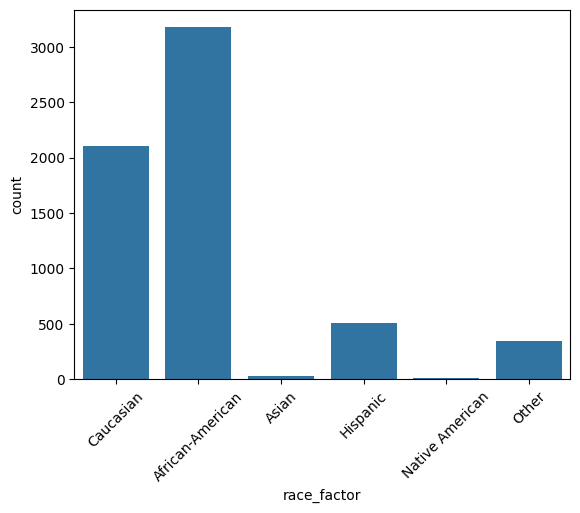

In [19]:
sns.countplot(data=df, x="race_factor")
plt.xticks(rotation=45)
plt.show()

In [20]:
# Logistic Regression Model
# Implement a logistic regression model to predict the likelihood of a defendant receiving a high-risk score.

In [21]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.logit(
    "score_factor ~ C(gender_factor) + C(age_factor) + C(race_factor) + priors_count + C(crime_factor) + two_year_recid",
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_factor   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        00:00:21   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.5255      0.079    

In [22]:
# Model Interpretation
# Model coefficients are converted into odds ratios to better understand the effect of each variable on the likelihood of receiving a high-risk score.

In [23]:
np.exp(model.params)

,0
Intercept,0.217504
C(gender_factor)[T.Female],1.247656
C(age_factor)[T.Less than 25],3.700213
C(age_factor)[T.Greater than 45],0.257784
C(race_factor)[T.African-American],1.611567
C(race_factor)[T.Asian],0.775370
C(race_factor)[T.Hispanic],0.651554
C(race_factor)[T.Native American],4.031779
C(race_factor)[T.Other],0.437645
C(crime_factor)[T.M],0.732537


In [24]:
# Predictions and Model Evaluation
# Generate predicted probabilities and classify observations using a 0.5 threshold. Model performance is evaluated using:
# confusion matrix
# accuracy
# precision
# recall
# false positive rate (FPR)
# false negative rate (FNR)

In [25]:
df["pred_prob"] = model.predict(df)

In [26]:
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, 1, 0)

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df["two_year_recid"], df["pred_class"])
cm

array([[2653,  710],
       [ 945, 1864]])

In [28]:
TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
FPR = FP / (FP + TN)
FNR = FN / (FN + TP)

accuracy, precision, recall, FPR, FNR

(np.float64(0.731853532080363),
 np.float64(0.7241647241647242),
 np.float64(0.6635813456746174),
 np.float64(0.21112102289622361),
 np.float64(0.3364186543253827))

In [29]:
# Fairness Analysis
# Evaluate model performance across racial groups by computing error rates (FPR and FNR) for each group.

In [30]:
race_metrics = df.groupby("race_factor", observed=False).apply(
    lambda x: pd.Series({
        "TP": ((x["pred_class"] == 1) & (x["two_year_recid"] == 1)).sum(),
        "TN": ((x["pred_class"] == 0) & (x["two_year_recid"] == 0)).sum(),
        "FP": ((x["pred_class"] == 1) & (x["two_year_recid"] == 0)).sum(),
        "FN": ((x["pred_class"] == 0) & (x["two_year_recid"] == 1)).sum(),
    }),
    include_groups=False
)

race_metrics["FPR"] = race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])
race_metrics["FNR"] = race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])

race_metrics

,TP,TN,FP,FN,FPR,FNR
race_factor,,,,,,
Caucasian,381,1148,133,441,0.103825,0.536496
African-American,1373,959,555,288,0.366579,0.173390
Asian,2,22,1,6,0.043478,0.750000
Hispanic,81,306,14,108,0.043750,0.571429
Native American,5,2,4,0,0.666667,0.000000
Other,22,216,3,102,0.013699,0.822581


In [31]:
ref = race_metrics.loc["Caucasian"]

race_metrics["delta_FPR"] = race_metrics["FPR"] - ref["FPR"]
race_metrics["delta_FNR"] = race_metrics["FNR"] - ref["FNR"]

race_metrics

,TP,TN,FP,FN,FPR,FNR,delta_FPR,delta_FNR
race_factor,,,,,,,,
Caucasian,381,1148,133,441,0.103825,0.536496,0.000000,0.000000
African-American,1373,959,555,288,0.366579,0.173390,0.262753,-0.363107
Asian,2,22,1,6,0.043478,0.750000,-0.060347,0.213504
Hispanic,81,306,14,108,0.043750,0.571429,-0.060075,0.034932
Native American,5,2,4,0,0.666667,0.000000,0.562842,-0.536496
Other,22,216,3,102,0.013699,0.822581,-0.090127,0.286084


Key Findings:
The results reveal notable disparities in model performance across racial groups. African-American defendants exhibit a significantly higher false positive rate compared to Caucasian defendants, indicating they are more likely to be incorrectly classified as high risk. Conversely, Caucasian defendants show a higher false negative rate, meaning they are more likely to be incorrectly classified as low risk.
These findings highlight important fairness concerns in the model and are consistent with conclusions from the original COMPAS analysis. There may be minor numerical differences due to differences between R and Python implementations.